### This notebook demonstrates how to use the raster.functions module in the ArcGIS API for Python to perform a weighted overlay analysis.  

The weighted overlay is a standard GIS analysis technique often used for generating surfaces representing site-suitability and travel-cost. This example calculates a generic travel-cost surface for land animal populations migrating to new regions in response to climate change.  The parameters used in this analysis are slope, elevation, and level of human modification to the terrain.  

The example in this notebook is intended to serve only as a technology demo.  The specific analysis
shown here is not based on any known scientific research.

# Connect to the GIS portal

In [56]:
# Connect to the Portal
from arcgis.gis import GIS
import getpass

password = getpass.getpass("Enter password:")
portal_gis = GIS('https://dev004543.esri.com/arcgis', 'djohnsonRA', password)
print("Successfully connected to {0} as {1}".format(
      portal_gis.properties.name, portal_gis.properties.user.username))

Enter password:········
Successfully connected to ArcGIS Enterprise A as djohnsonRA


# Access the data for analysis

In [66]:
# Search for items tagged with 'Raster Analytics'
search_result = portal_gis.content.search(query="tags:Raster Analytics")
search_result

[<Item title:"NLCD_2011" type:Image Service owner:djohnsonRA>,
 <Item title:"USGS NED 30m" type:Image Service owner:djohnsonRA>,
 <Item title:"Human_Modification_for_North_America" type:Image Service owner:djohnsonRA>,
 <Item title:"San_Bernardino_County" type:Map Service owner:djohnsonRA>,
 <Item title:"Conterminous_USA_BorderMask" type:Image Service owner:djohnsonRA>,
 <Item title:"Ventura_County" type:Feature Service owner:djohnsonRA>,
 <Item title:"Riverside_County" type:Map Service owner:djohnsonRA>,
 <Item title:"Human_Modified_Index" type:Image Service owner:djohnsonRA>]

### Area of Interest layer

<Item title:"Ventura_County" type:Feature Service owner:djohnsonRA>
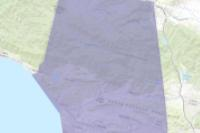

In [68]:
# Get a reference to the Ventura County feature layer item
item_vc = search_result[5]
item_vc

In [69]:
lyr_vc = item_vc.layers[0]
lyr_vc

<FeatureLayer url:"https://dev004543.esri.com/arcgis/rest/services/Hosted/Ventura_County/FeatureServer/0">

In [70]:
item_vc.spatialReference

'North_America_Albers_Equal_Area_Conic'

In [71]:
map1 = portal_gis.map('Ventura County, CA')
map1.add_layer(lyr_vc)
map1

In [72]:
# Query the Ventura County layer
qry = lyr_vc.query(where='1=1')
type(qry)

arcgis.features.feature.FeatureSet

In [73]:
# Get the geometry of the feature in the Ventura County layer
geom_aoi = qry.features[0].geometry
geom_aoi['spatialReference'] = qry.spatial_reference
geom_aoi

{'rings': [[[-1967842.1794000007, -370513.0398999993],
   [-1961856.9065000005, -421021.51070000045],
   [-1960578.5079999994, -435390.5976999998],
   [-1961514.9673999995, -440618.72509999946],
   [-1964837.7777999993, -439658.0892999992],
   [-1966941.1860000007, -447832.2960000001],
   [-1977348.9892999995, -445342.73069999926],
   [-1992184.0923999995, -452465.6654000003],
   [-1993599.1243999992, -457403.1242999993],
   [-2014182.7109999992, -439510.6964999996],
   [-2015866.9598999992, -428045.8825000003],
   [-2030303.3211000003, -407941.8881000001],
   [-2026866.2112000007, -406239.5462999996],
   [-2026349.7370999996, -403092.5946999993],
   [-2024360.4991999995, -401143.7042999994],
   [-2011738.9164000005, -349622.6163999997],
   [-2006579.8484000005, -350826.5583999995],
   [-2007108.5264999997, -354027.1528999992],
   [-1998770.5086000003, -356375.6348000001],
   [-1998922.7149999999, -357701.8984999992],
   [-1996313.6680999994, -358501.41860000044],
   [-1997396.95859999

### DEM layer

<Item title:"USGS NED 30m" type:Image Service owner:djohnsonRA>
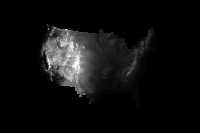

In [74]:
# Get a reference to the DEM image service item
item_dem = search_result[1]
item_dem

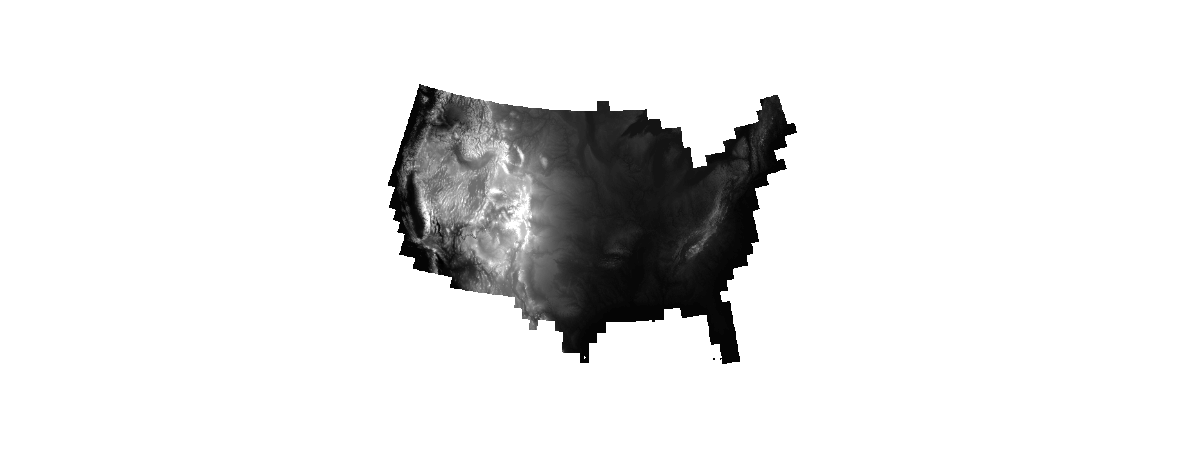

In [75]:
# Get a reference to the layer in the DEM image service item
lyr_dem = item_dem.layers[0]
lyr_dem

In [76]:
lyr_dem.properties.spatialReference

{
  "wkid": 102008,
  "latestWkid": 102008
}

In [77]:
# Import the geocode function from the API and get the location of Ventura County
from arcgis.geocoding import geocode
ventura_county = geocode('Ventura County', out_sr=lyr_dem.properties.spatialReference)[0]
ventura_county

{'address': 'Ventura County, California, United States',
 'attributes': {'AddBldg': '',
  'AddNum': '',
  'AddNumFrom': '',
  'AddNumTo': '',
  'Addr_type': 'POI',
  'City': '',
  'Country': 'USA',
  'DisplayX': -119.017601,
  'DisplayY': 34.466659,
  'Distance': 0,
  'LangCode': '',
  'Loc_name': 'Gaz.WorldGazetteer.POI1',
  'Match_addr': 'Ventura County, California, United States',
  'Nbrhd': '',
  'Phone': '',
  'PlaceName': 'Ventura County',
  'Place_addr': '',
  'Postal': '',
  'PostalExt': '',
  'Rank': '10',
  'Region': 'California',
  'Score': 100,
  'Side': '',
  'StAddr': '',
  'StDir': '',
  'StName': '',
  'StPreDir': '',
  'StPreType': '',
  'StType': '',
  'Subregion': 'Ventura County',
  'Type': 'County',
  'URL': '',
  'X': -119.017601,
  'Xmax': -118.589601,
  'Xmin': -119.445601,
  'Y': 34.466659,
  'Ymax': 34.894659,
  'Ymin': 34.038659},
 'extent': {'xmax': -1940216.9517151462,
  'xmin': -2036744.1857890293,
  'ymax': -349839.07978355326,
  'ymin': -464865.610264176

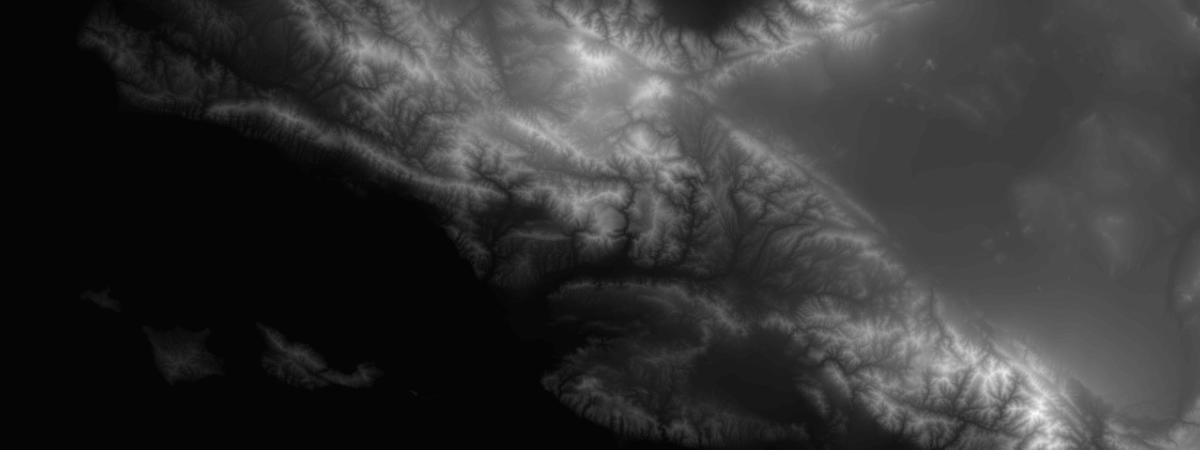

In [78]:
# Get a layer reference from the DEM image service item
#lyr_dem = item_dem.layers[0]
# Display an exported image of the DEM layer with the bounding box set to Ventura County.
lyr_dem.extent = ventura_county['extent']
lyr_dem

### Slope analysis layer

In [79]:
# Import the raster functions from the API
from arcgis.raster.functions import *

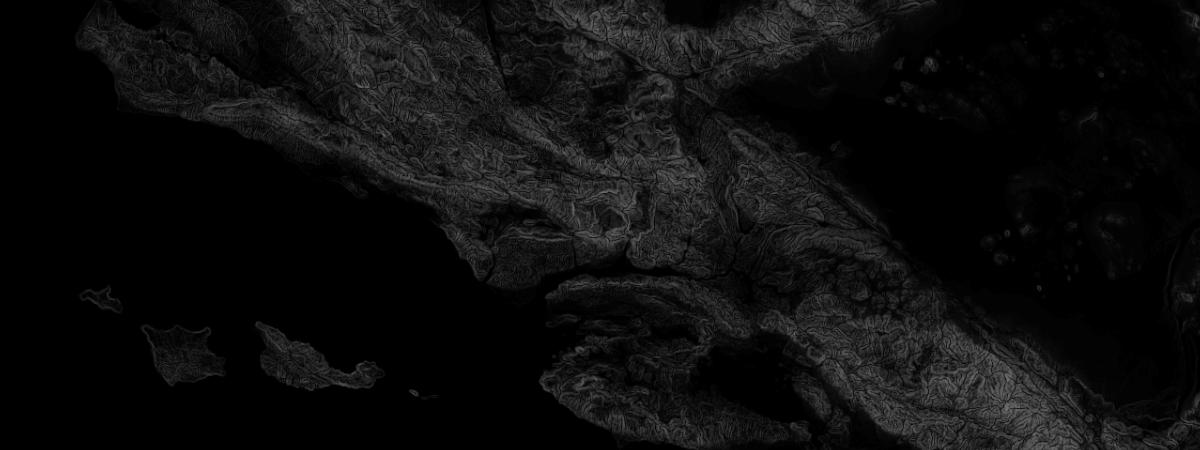

In [80]:
# Derive a slope layer from the DEM layer
lyr_slope = slope(dem=lyr_dem,slope_type='DEGREE', z_factor=1)
# Display an exported image of the slope layer with the bounding box set to Ventura County.
lyr_slope.extent= ventura_county['extent']
lyr_slope

### Human Modified Index analysis layer

In [81]:
# Get a reference to the Human Modified Index image service item.
# This dataset is based on research on the degree of human modification to the landscape, on a scale 
# of 0 - 1, where 0.0 indicates unmodified natural landscape and 1.0 indicates the landscape is 
# completely modified by human activity.

item_hmi = search_result[7]
item_hmi

<Item title:"Human_Modified_Index" type:Image Service owner:djohnsonRA>

In [82]:
lyr_hmi = item_hmi.layers[0]
lyr_hmi.properties.spatialReference

{
  "wkid": 102008,
  "latestWkid": 102008
}

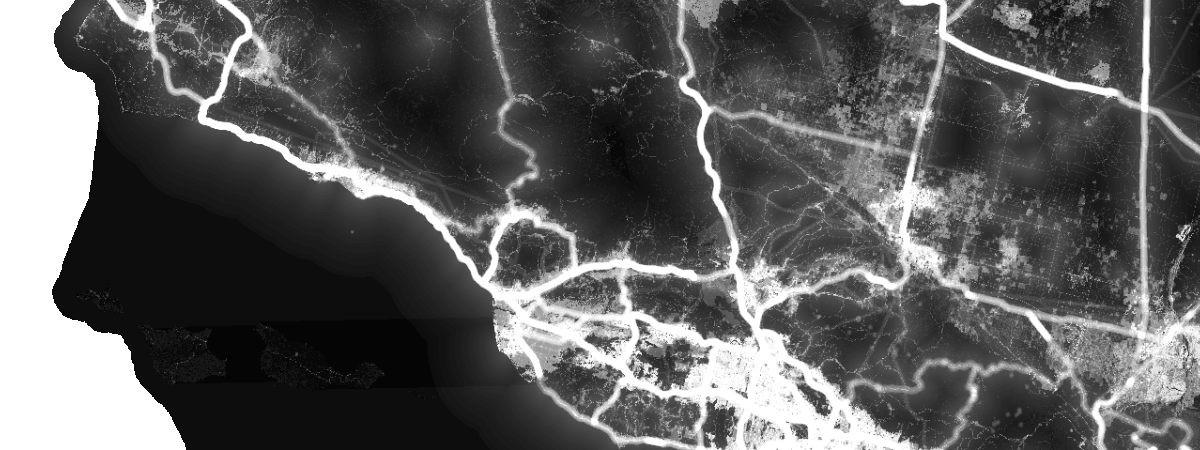

In [83]:
# Display an exported image of the HMI layer with the bounding box set to Ventura County.
lyr_hmi.extent = ventura_county['extent']
lyr_hmi

# Clip the analysis data to the geometry of the AOI

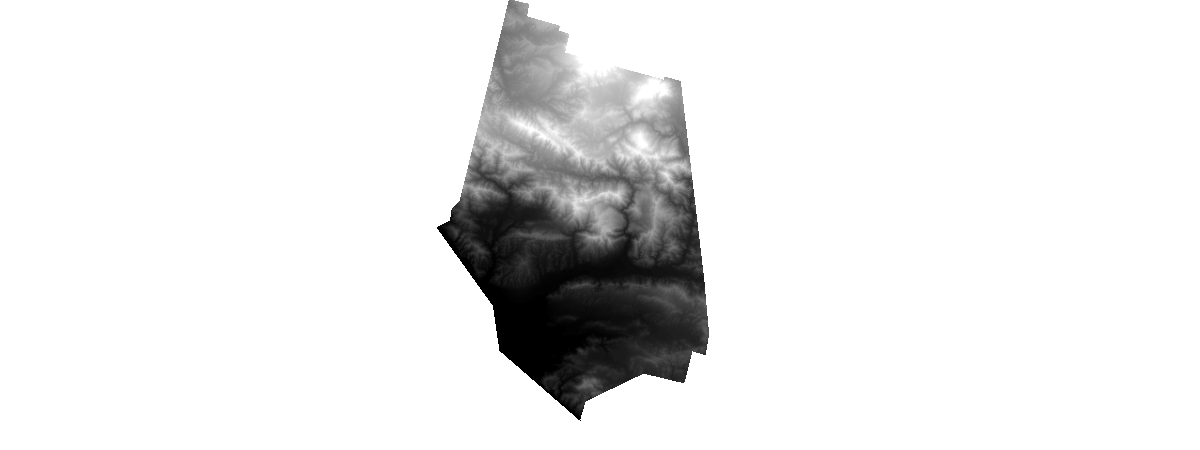

In [84]:
elev_clipped = clip(raster=lyr_dem, geometry=geom_aoi)
elev_clipped.extent= ventura_county['extent']
elev_clipped

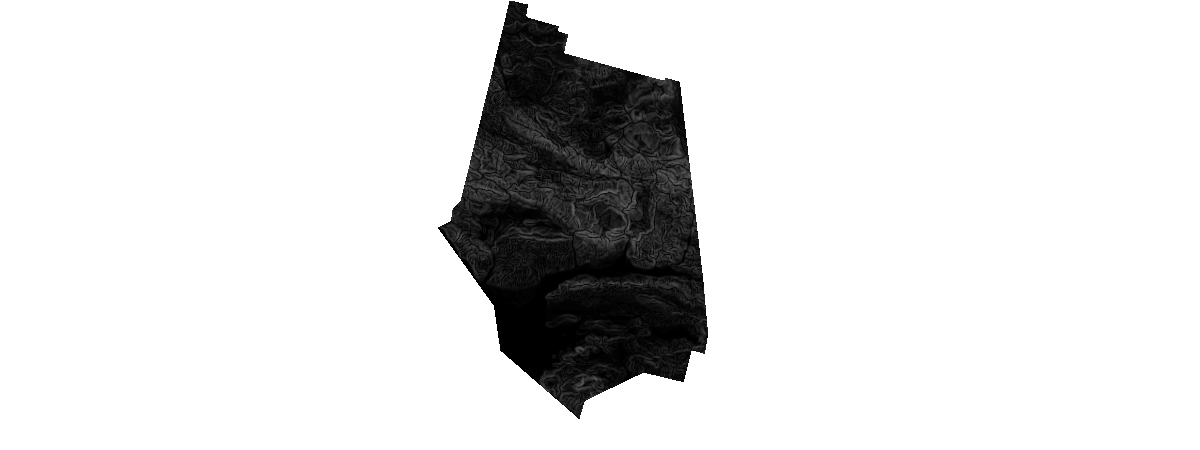

In [85]:
slope_clipped = slope(dem=elev_clipped, z_factor=1, ps_power=0.664, psz_factor=0.024, remove_edge_effect=False)
slope_clipped

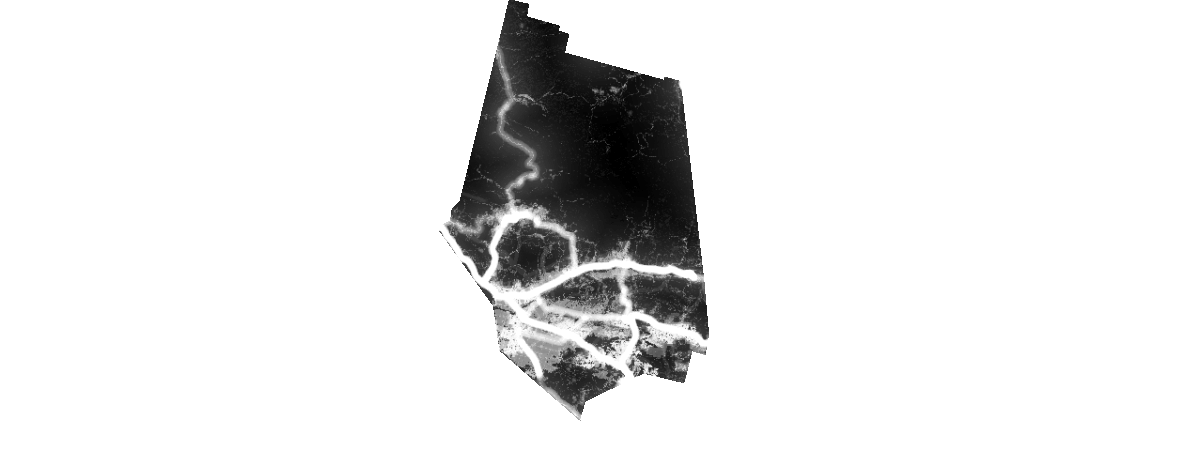

In [86]:
hmi_clipped = clip(raster=lyr_hmi, geometry=geom_aoi)
hmi_clipped

# Perform a weighted overlay analysis

## Generate intermediate analysis outputs

### Reclassify the analysis datasets to a common scale of 1 - 9

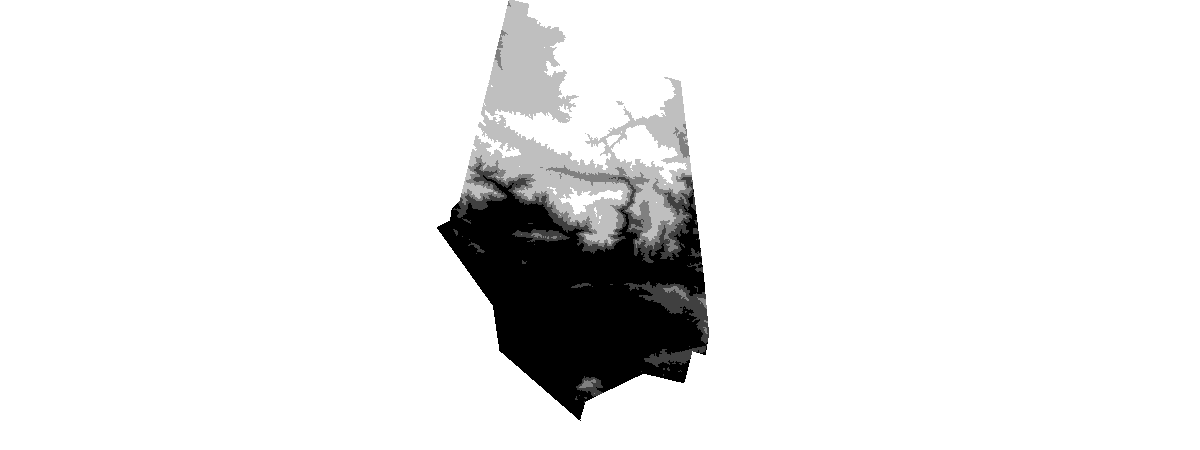

In [87]:
# Reclassify the elevation data to a scale of 1 - 9,
# where 1 = lowest elevation terrain that is therefore the easist to traverse,
# and 9 = highest elevation terrain that is the most difficult to traverse.
elev_remap = remap(raster=elev_clipped,
                       input_ranges=[-90,250, 250,500, 500,750, 750,1000, 1000,1500, 
                                     1500,2000, 2000,2500, 2500,3000, 3000,5000],
                       output_values=[1,2,3,4,5,6,7,8,9])
elev_remap

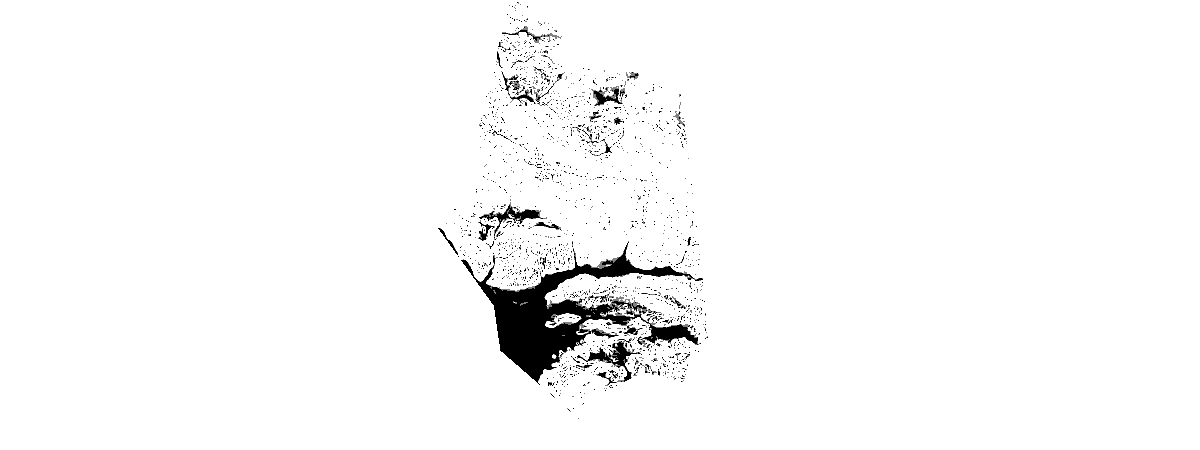

In [88]:
# Reclassify the slope data to a scale of 1 - 9, 
# where 1 = terrain that has the lowest slopes and is therefore thes easiest to traverse, 
# and 9 = terrain that has the highest slopes and is therefore the most difficult to traverse.
slope_remap = remap(raster=slope_clipped, 
                        input_ranges=[0,1, 1,2, 2,3, 3,5, 5,7, 7,9, 9,12, 12,15, 15,100],
                        output_values=[1,2,3,4,5,6,7,8,9]) 
slope_remap

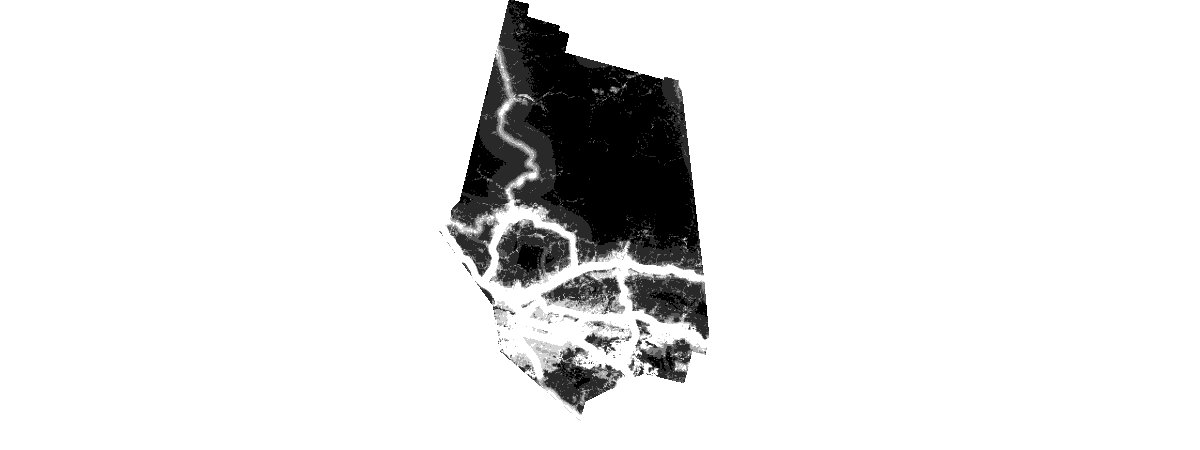

In [89]:
# Reclassify the Human Modified Index data to a scale of 1 - 9,
# where 1 = Terrain that is the least impacted by human activities 
# and is the easiest, or least hazardous to traverse,
# and 9 = terrain that is the most impacted by human activites
# and is therefore the most difficult or hazardous to traverse.
hmi_remap = remap(raster=hmi_clipped,
                  input_ranges=[0.0,0.1, 0.1,0.2, 0.2,0.3, 0.3,0.4, 0.4,0.5,
                                0.5,0.6, 0.6,0.7, 0.7,0.8, 0.8,1.1],
                  output_values=[1,2,3,4,5,6,7,8,9])
hmi_remap

### Display the reclassified data with a colormap

In [90]:
# Create a colormap for rendering the intermediate and final analysis results.
clrmap=  [[1,  38, 115,0],[2,  86, 148,0],[3,  0x8B, 0xB5,0],[4,  0xC5, 0xDB,0],
         [5, 255, 255, 0],[6,  0xFF, 0xC3,0],[7, 0xFA, 0x8E, 0],[8,  0xF2, 0x55,0],
         [9, 0xE6, 0, 0]]

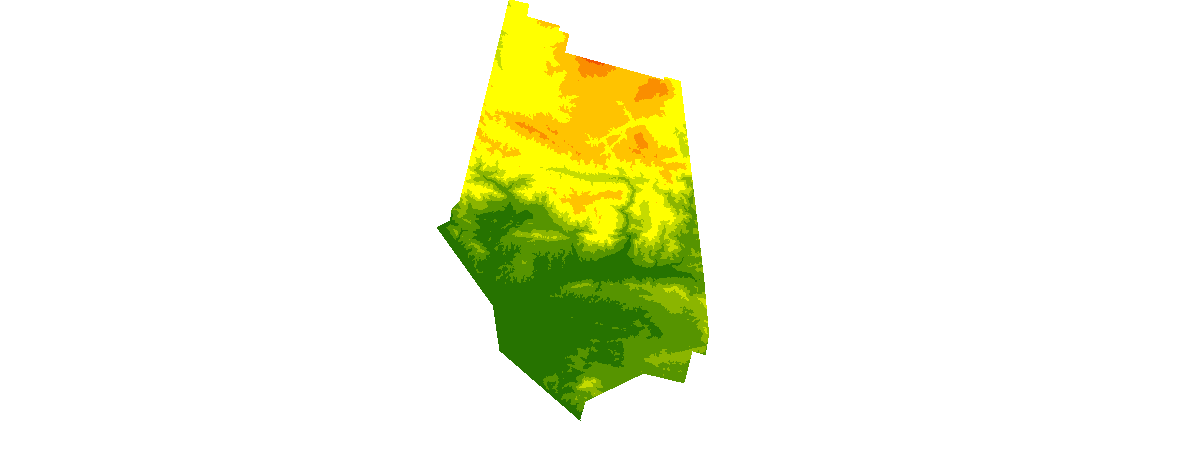

In [91]:
# Export an colormapped-image of the reclassified elevation data
colormap(elev_remap, colormap=clrmap)

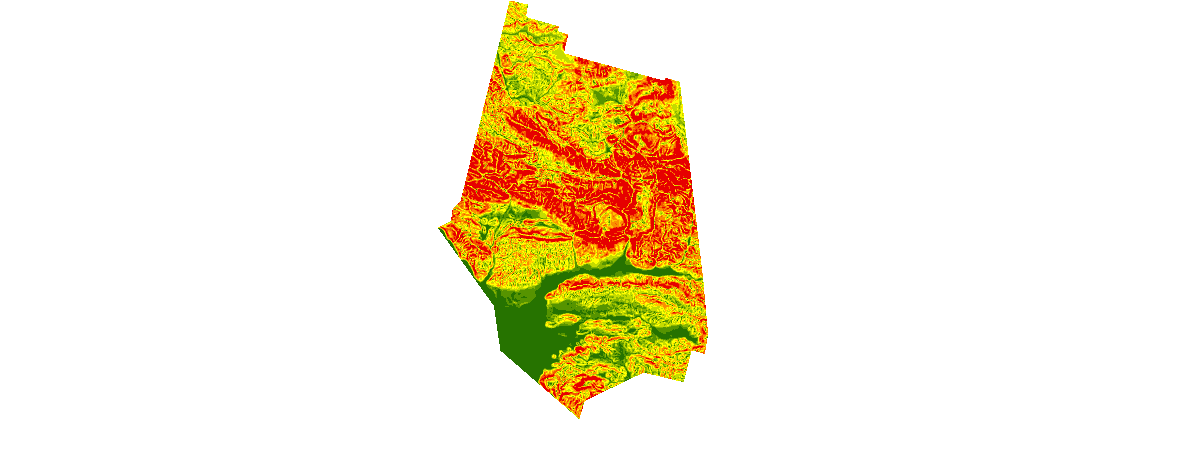

In [92]:
# Display a colormapped-image of the reclassified slope data
colormap(slope_remap, colormap=clrmap)

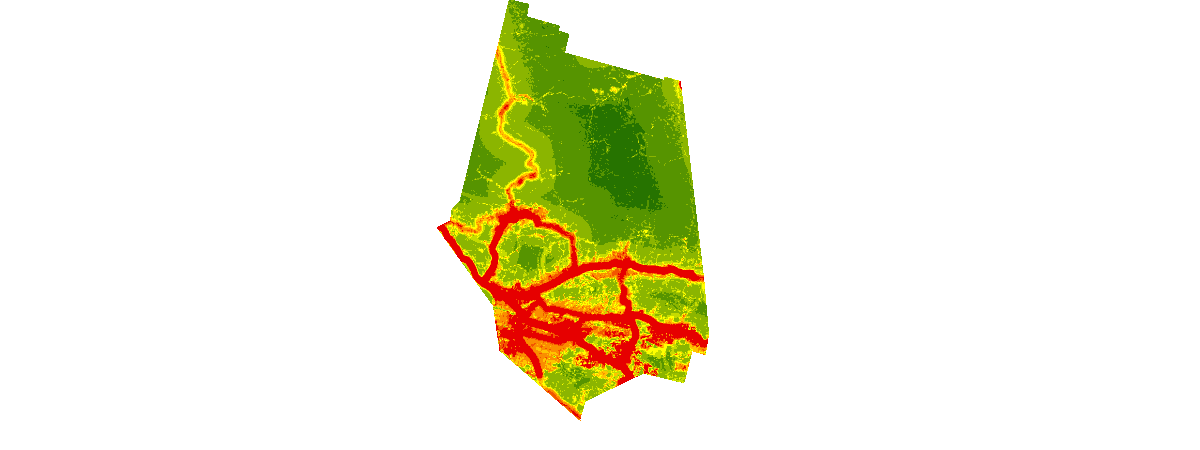

In [93]:
# Display a colormapped-image of the reclassified HMI data
colormap(hmi_remap, colormap=clrmap)

### Generate the final analysis output

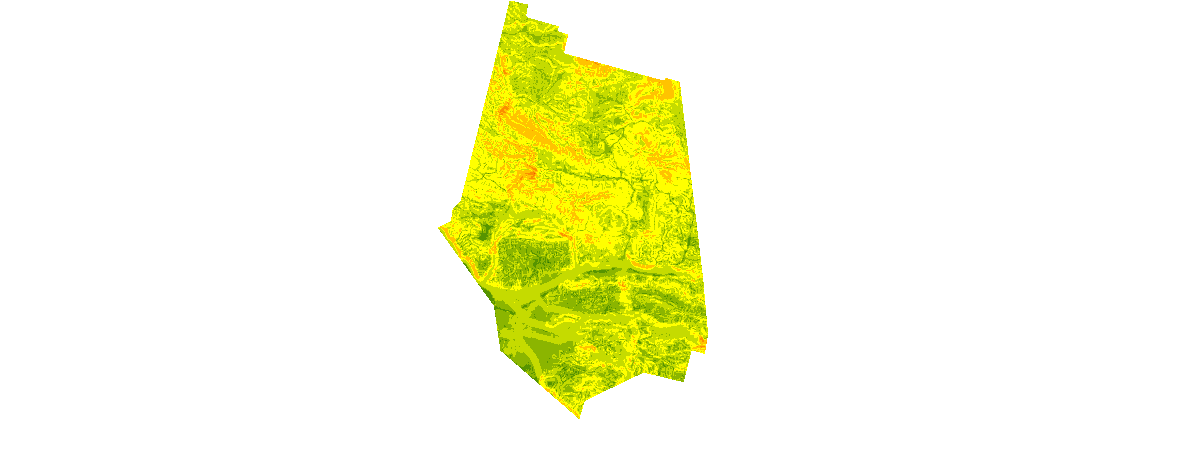

In [94]:
# Generate a final result using the intermediate datasets generated above:
#  - Apply weights to the reclassified datasets
#    - the sum of the weights must equal 1.0
#    - assign higher weight values to datasets that are considered to have more importance to the result
#  - Calculate the sum of the weighted, reclassified datasets (i.e. the weighted overlay)
#  - Display the result with a colormap, where red = high travel cost, and green = low travel cost

# In this example, each variable, elevation, slope, and HMI and given equal weight.
weighted_overlay_1 = colormap(0.34 * elev_remap + 0.33 * slope_remap + 0.33 * hmi_remap, 
                              colormap=clrmap)
weighted_overlay_1

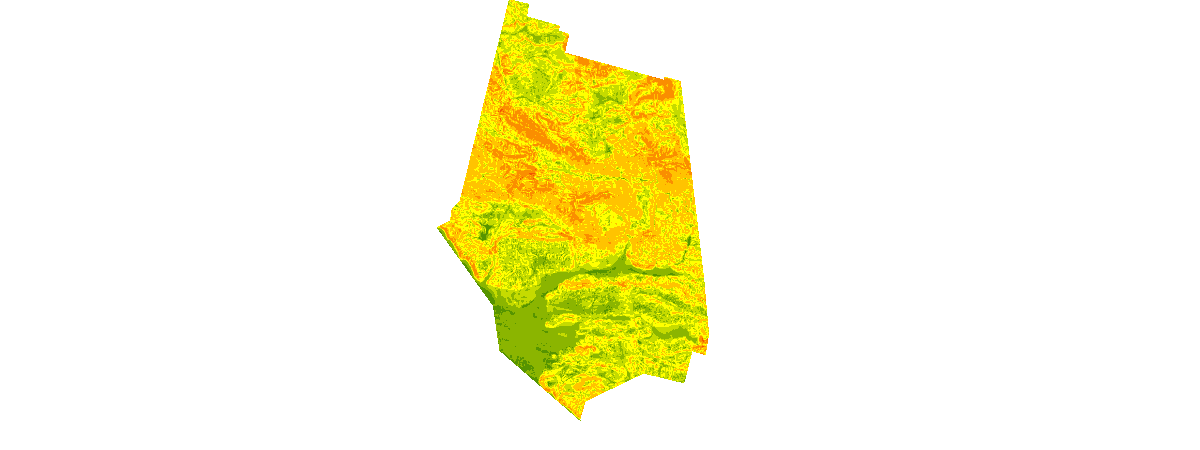

In [95]:
# Generate a final result from start to finish in a single operation.
# In this example, slope is assigned a higher weight than elevation or degree of human modification
# on the assumption that slope would have a greater affect of travel cost than the other variables.
weighted_overlay_2 = colormap(
    raster=
    (
        # Elevation layer
        0.25 * remap(raster=clip(raster=lyr_dem, geometry=geom_aoi), 
                    input_ranges=[-90,250, 250,500, 500,750, 750,1000, 1000,1500, 
                                  1500,2000, 2000,2500, 2500,3000, 3000,5000],
                    output_values=[1,2,3,4,5,6,7,8,9]) 
        + 
        # Slope layer
        0.5 * remap(raster=clip(raster=lyr_slope, geometry=geom_aoi), 
                     input_ranges=[0,1, 1,2, 2,3, 3,5, 5,7, 7,9, 9,12, 12,15, 
                                   15,100],
                     output_values=[1,2,3,4,5,6,7,8,9]) 
        + 
        # Human modified index layer
        0.25 * remap(raster=clip(raster=lyr_hmi, geometry=geom_aoi),
                     input_ranges=[0.0,0.1, 0.1,0.2, 0.2,0.3, 0.3,0.4, 0.4,0.5,
                                   0.5,0.6, 0.6,0.7, 0.7,0.8, 0.8,1.1],
                     output_values=[1,2,3,4,5,6,7,8,9])
    ),
    colormap=clrmap
)
weighted_overlay_2


In [96]:
# Display the result in a map
weighted_overlay_2
map2 = portal_gis.map('Ventura County, USA')
map2.add_layer(weighted_overlay_2)
map2

In [97]:
# Generate a persistent result at source resolution using Raster Analytics
import arcgis
arcgis.raster.analytics.is_supported(portal_gis)

True

In [98]:
from arcgis.raster.analytics import generate_raster

In [99]:
import arcgis.raster.analytics as ra
import datetime
starttime = datetime.datetime.now()
ra_result = weighted_overlay_2.save('WeightedOverlayResult_VenturaCounty')
endtime = datetime.datetime.now()

In [106]:
c = endtime - starttime
str(c)

'1:06:42.382892'

In [102]:
map3 = portal_gis.map('Ventura County, California')
map3.add_layer(ra_result)
map3